In [1]:
from autocvd import autocvd
autocvd(num_gpus = 1)


import numpy as np
import matplotlib.pyplot as plt
from jax import vmap
import jax.numpy as jnp

from observational_realism import galc_to_icrs_spherical, icrs_equatorial_to_galc


In [2]:
# Checking the position on the sky of GD-1 progenitor using astropy (consistency)

from astropy.coordinates import Galactocentric, ICRS, CartesianDifferential, CartesianRepresentation
import astropy.units as u

# Define position and velocity
pos = (11.8, 0.79, 6.4)  # kpc
vel = (109.5, -254.5, -90.3)  # km/s

# Create CartesianRepresentation with velocity (differential)
cartesian = CartesianRepresentation(
    x=pos[0]*u.kpc, y=pos[1]*u.kpc, z=pos[2]*u.kpc,
    differentials=CartesianDifferential(
        d_x=vel[0]*u.km/u.s, d_y=vel[1]*u.km/u.s, d_z=vel[2]*u.km/u.s
    )
)

# Create Galactocentric coordinate
gc = Galactocentric(cartesian)

# Transform to ICRS
icrs = gc.transform_to(ICRS())

# Print ICRS spherical coordinates and proper motions
print("RA:", icrs.ra.deg)
print("Dec:", icrs.dec.deg)
print("Distance:", icrs.distance)
print("PM RA:", icrs.pm_ra_cosdec)
print("PM Dec:", icrs.pm_dec)
print("Radial velocity:", icrs.radial_velocity)


# --- Inverse transformation: ICRS back to Galactocentric Cartesian ---

# Create a new ICRS object with all phase-space info
icrs_back = ICRS(
    ra=icrs.ra, dec=icrs.dec, distance=icrs.distance,
    pm_ra_cosdec=icrs.pm_ra_cosdec, pm_dec=icrs.pm_dec,
    radial_velocity=icrs.radial_velocity
)

# Transform back to Galactocentric
gc_back = icrs_back.transform_to(Galactocentric())

# Extract Cartesian position and velocity
cart_back = gc_back.cartesian
vel_back = cart_back.differentials['s']

print("\nRecovered Galactocentric Cartesian:")
print("X [kpc]:", cart_back.x)
print("Y [kpc]:", cart_back.y)
print("Z [kpc]:", cart_back.z)
print("Vx [km/s]:", vel_back.d_x)
print("Vy [km/s]:", vel_back.d_y)
print("Vz [km/s]:", vel_back.d_z)

RA: 251.71683441276554
Dec: -16.967150231506142
Distance: 20.933306366660915 kpc
PM RA: -2.1001508916626936 mas / yr
PM Dec: -4.766797059251095 mas / yr
Radial velocity: 43.17099627446797 km / s

Recovered Galactocentric Cartesian:
X [kpc]: 11.800000000000002 kpc
Y [kpc]: 0.7899999999999991 kpc
Z [kpc]: 6.3999999999999995 kpc
Vx [km/s]: 109.5 km / s
Vy [km/s]: -254.5000000000001 km / s
Vz [km/s]: -90.30000000000003 km / s


In [3]:
# GD1 prior center for present day progenitor: 
pos = (11.8,0.79,6.4) # kpc
vel = (109.5, - 254.5, -90.3) #km / s
progenitor_gd1 = jnp.array([*pos, *vel]).reshape(1,6)
progenitor_gd1_spherical = galc_to_icrs_spherical(progenitor_gd1)
print("Progenitor GD1 (spherical): ", progenitor_gd1_spherical)
icrs_array = jnp.array([progenitor_gd1_spherical[:, 0], progenitor_gd1_spherical[:, 1], progenitor_gd1_spherical[:, 2],
                        progenitor_gd1_spherical[:, 3], progenitor_gd1_spherical[:, 4], progenitor_gd1_spherical[:, 5]]).reshape(1,6)

galc_array = icrs_equatorial_to_galc(icrs_array)
print("Galactic Cartesian Coordinates and Velocities:")
print('Progenitor GD1 (galc) beginning: ', progenitor_gd1)
print('Progenitor GD1 (galc) from spherical: ', galc_array)

Progenitor GD1 (spherical):  [[251.71681   -16.967155   20.933306   -2.1001513  -4.766797   43.17105  ]]
Galactic Cartesian Coordinates and Velocities:
Progenitor GD1 (galc) beginning:  [[  11.8     0.79    6.4   109.5  -254.5   -90.3 ]]
Progenitor GD1 (galc) from spherical:  [[  11.799997     0.7899982    6.4000025  109.50002   -254.50005
   -90.29997  ]]


In [ ]:
# Call for galstreams

# Let's check the tracs on galstreams
import galstreams

#Set print_topcat_friendly_files=True the first time to create TOPCAT friendly files
mws = galstreams.MWStreams(verbose=False, implement_Off=False, print_topcat_friendly_files=False);

# From carthesian to ircs spherical

In [2]:
data_carthesian = np.load('./training_set_odisseo.npz')['sim_data'][:200]
data_spherical = vmap(galc_to_icrs_spherical)(jnp.array(data_carthesian))
print('data_carthesian shape:', data_carthesian.shape)  # (N_samples, N_particles, 6)
print('data_spherical icrs shape:', data_spherical.shape)  # (N_samples, N_particles, 6)

data_carthesian shape: (200, 1000, 6)
data_spherical icrs shape: (200, 1000, 6)


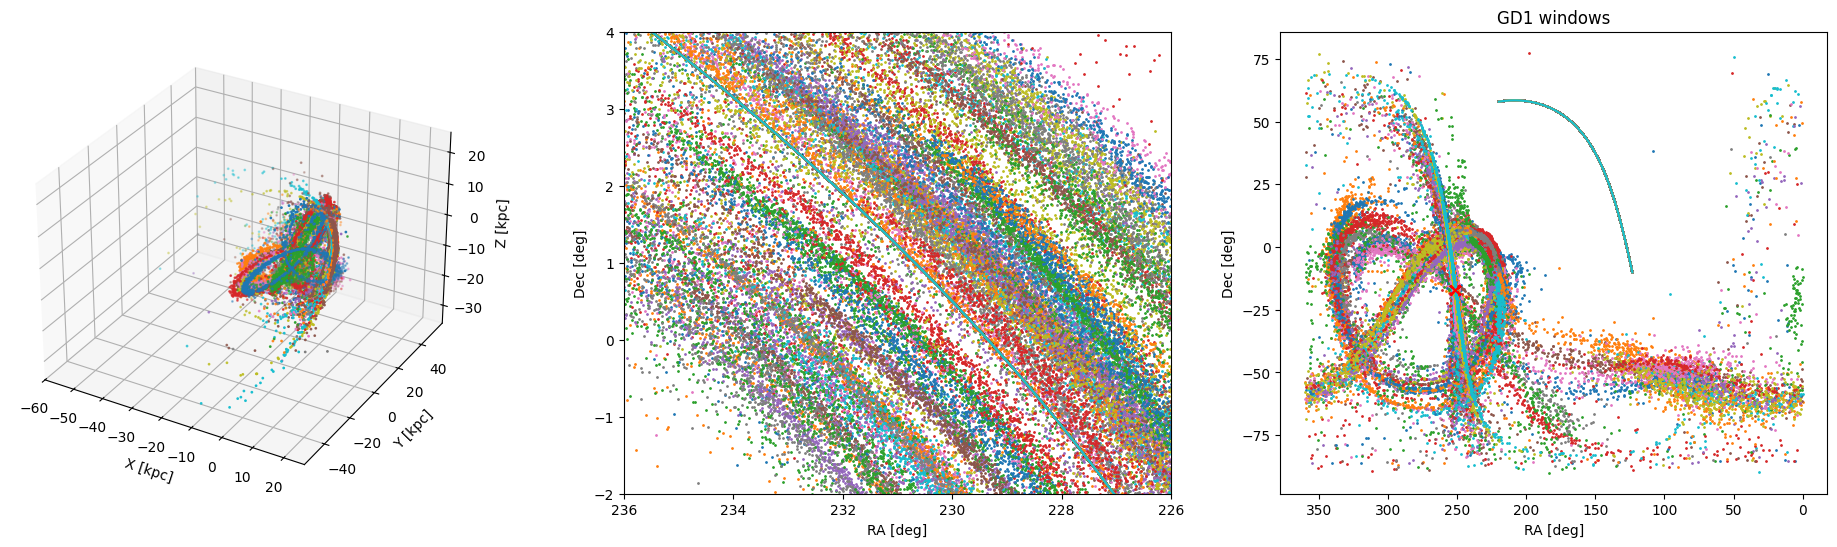

In [35]:
fig = plt.figure(figsize=(24, 6))
ax = fig.add_subplot(131, projection='3d')
ax2 = fig.add_subplot(132)
ax3 = fig.add_subplot(133)

# GD1 prior center for present day progenitor: 
pos = (11.8,0.79,6.4) # kpc
vel = (109.5, - 254.5, -90.3) #km / s
progenitor_gd1 = jnp.array([*pos, *vel]).reshape(1,6)
progenitor_gd1_spherical = galc_to_icrs_spherical(progenitor_gd1)
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)[0]
track_Pal5 = mws[track_name_Pal5].track

track_name_GD1 = mws.get_track_names_for_stream('GD-1', On_only=True)[0]
track_GD1 = mws[track_name_GD1].track

for i in range(data_carthesian.shape[0]):
    ax.scatter(data_carthesian[i, :, 0], data_carthesian[i, :, 1], data_carthesian[i, :, 2], s=1)
    ax.set_xlabel('X [kpc]')
    ax.set_ylabel('Y [kpc]')
    ax.set_zlabel('Z [kpc]')
    ax2.scatter(data_spherical[i, :, 0], data_spherical[i, :, 1], s=1)
    ax2.plot(track_Pal5.ra, track_Pal5.dec, label=f'{track_name_Pal5} track from galstreams')
    ax2.set_xlabel('RA [deg]')
    ax2.set_ylabel('Dec [deg]')

    ax3.scatter(data_spherical[i, :, 0], data_spherical[i, :, 1], s=1)
    ax3.scatter(progenitor_gd1_spherical[0, 0], progenitor_gd1_spherical[0, 1], color='red', s=50, marker='x')
    ax3.plot(track_GD1.ra, track_GD1.dec, label=f'{track_name_GD1} track from galstreams')
    ax3.set_xlabel('RA [deg]')
    ax3.set_ylabel('Dec [deg]')

ax2.set_xlim(226, 236 )
ax2.set_ylim(-2, 4)
ax2.invert_xaxis()

# GD1 window from https://arxiv.orpip install git+https://github.com/cmateu/galstreamsg/pdf/1801.08948
# ax3.set_xlim(140, 180)
# ax3.set_ylim(20, 60)
ax3.invert_xaxis()
ax3.set_title('GD1 windows')
plt.show()




# Pal5 track

track pal5 <SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, kpc)
    [(242.09382462,  6.88309464, 22.02340828),
     (242.08670271,  6.87558633, 22.02333424),
     (242.07954519,  6.86813366, 22.02325892), ...,
     (224.67592037, -4.79218842, 19.09368606),
     (224.66687367, -4.79668186, 19.09096063),
     (224.65738999, -4.80051507, 19.08823394)]
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    [(-2.12850417, -2.34952027, 999.00002274),
     (-2.12922183, -2.34945636, 999.00002274),
     (-2.12993892, -2.34939303, 999.00002274), ...,
     (-2.77331871, -3.06772628, 999.00002188),
     (-2.77323034, -3.0684521 , 999.00002188),
     (-2.77314357, -3.06917651, 999.00002188)]>


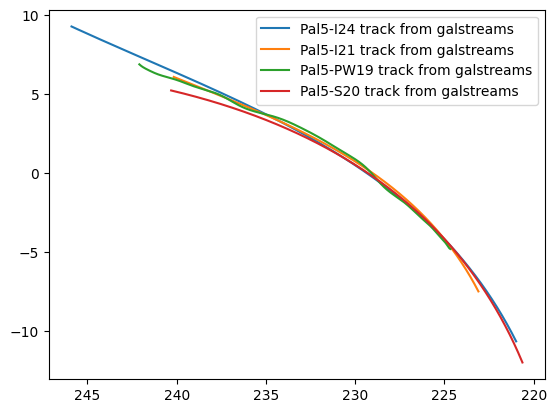

In [32]:

print('track pal5', mws['Pal5-PW19'].track)
fig = plt.figure()
ax = fig.add_subplot(111)
for name in mws.get_track_names_for_stream('Pal5', On_only=True):
    track = mws[name].track
    ax.plot(track.ra, track.dec, label=f'{name} track from galstreams')
    ax.legend()
ax.invert_xaxis()


# GD1 track

In [33]:
mws.get_track_names_for_stream('GD-1', On_only=True)

['GD-1-I21', 'GD-1-I24', 'GD-1-PB18']

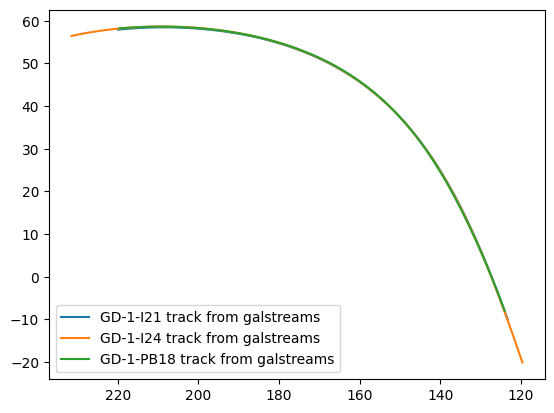

In [34]:
fig = plt.figure()
ax = fig.add_subplot(111)
for name in mws.get_track_names_for_stream('GD-1', On_only=True):
    track = mws[name].track
    ax.plot(track.ra, track.dec, label=f'{name} track from galstreams')
    ax.legend()
ax.invert_xaxis()